In [1]:
# Notebook to define and evaluate a Siamese UNet with a custom weighting schema 

In [2]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [3]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from  src.model_siamese import SiameseUNet
from torch.amp import GradScaler

scaler = GradScaler('cuda')

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [ ]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 4
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 15
BASE_FEATURES = 24
SAVE_PATH = "best_siamese_unet_combo.pth"

In [6]:
# Create Data Splits
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [7]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=True, augment_train=True)

In [8]:
# Sanity check
pre, post, masks = next(iter(train_loader))

print(f"Pre image:  {pre.shape}")    # [B, 3, H, W]
print(f"Post image: {post.shape}")   # [B, 3, H, W]
print(f"Masks:      {masks.shape}")  # [B, H, W]
print(f"Mask range: {masks.min()} – {masks.max()}")
print(f"Device:     {pre.device}")

Pre image:  torch.Size([4, 3, 512, 512])
Post image: torch.Size([4, 3, 512, 512])
Masks:      torch.Size([4, 512, 512])
Mask range: 0 – 4
Device:     cpu


In [ ]:
# Loss — ComboLoss (CE + Tversky)
"""class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)
"""
class_weights = torch.tensor([0.5, 2.0, 20.0, 18.0, 4.0], dtype=torch.float32).to(device)

In [10]:
# Model
model = SiameseUNet(
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES,
    in_channels=3 # only include 3 channels for Siamese
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device)

Model parameters: 5,839,277
cuda:0


In [ ]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights,
                      ce_weight=0.3,
                      tversky_weight=0.7, tversky_alpha=0.85, tversky_beta=0.15, tversky_gamma=0.6,
                      num_classes=NUM_CLASSES).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay = 1e-4)

#scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=2e-4, steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS, pct_start=0.1, div_factor=10, final_div_factor=100)

In [12]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True,
    siamese = True, scaler=scaler)



Epoch 1/50  (lr=3.00e-05)
  Train Loss: 1.0627  |  Val Loss: 0.9675
  Train mIoU: 0.1600  |  Val mIoU: 0.2075
  Train Acc:  0.5782  |  Val Acc:  0.8323
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.8339   0.9893   0.8415
    Minor             0.1703   0.1853   0.6774
    Major             0.0010   0.0010   0.1454
    Destroyed         0.0078   0.0079   0.2742
    Unclassified      0.0244   0.0860   0.0330
  *** Saved new best model (mIoU=0.2075) ***



Epoch 2/50  (lr=5.58e-05)
  Train Loss: 0.9086  |  Val Loss: 0.8714
  Train mIoU: 0.2878  |  Val mIoU: 0.2164
  Train Acc:  0.8635  |  Val Acc:  0.8520
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.8638   0.9903   0.8712
    Minor             0.2021   0.2556   0.4913
    Major             0.0012   0.0012   0.6857
    Destroyed         0.0087   0.0089   0.3184
    Unclassified      0.0063   0.3735   0.0064
  *** Saved new best model (mIoU=0.2164) ***



Epoch 3/50  (lr=1.23e-04)
  Train Loss: 0.8531  |  Val Loss: 0.8457
  Train mIoU: 0.3154  |  Val mIoU: 0.2271
  Train Acc:  0.8853  |  Val Acc:  0.8619
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.8673   0.9949   0.8712
    Minor             0.2152   0.2365   0.7053
    Major             0.0011   0.0012   0.2589
    Destroyed         0.0116   0.0122   0.2061
    Unclassified      0.0400   0.2926   0.0443
  *** Saved new best model (mIoU=0.2271) ***



Epoch 4/50  (lr=2.07e-04)
  Train Loss: 0.8292  |  Val Loss: 0.8413
  Train mIoU: 0.3360  |  Val mIoU: 0.2318
  Train Acc:  0.8934  |  Val Acc:  0.8748
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.8856   0.9942   0.8902
    Minor             0.2108   0.2469   0.5907
    Major             0.0015   0.0015   0.3888
    Destroyed         0.0116   0.0117   0.5309
    Unclassified      0.0494   0.0868   0.1028
  *** Saved new best model (mIoU=0.2318) ***



Epoch 5/50  (lr=2.74e-04)
  Train Loss: 0.8163  |  Val Loss: 0.8128
  Train mIoU: 0.3456  |  Val mIoU: 0.2934
  Train Acc:  0.8990  |  Val Acc:  0.9038
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9056   0.9941   0.9105
    Minor             0.2925   0.3167   0.7929
    Major             0.0006   0.0006   0.0459
    Destroyed         0.0178   0.0183   0.3894
    Unclassified      0.2504   0.6000   0.3006
  *** Saved new best model (mIoU=0.2934) ***


...


Epoch 23/50  (lr=2.06e-04)
  Train Loss: 0.7139  |  Val Loss: 0.7761
  Train mIoU: 0.4646  |  Val mIoU: 0.3385
  Train Acc:  0.9344  |  Val Acc:  0.9463
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9544   0.9943   0.9596
    Minor             0.4236   0.5184   0.6986
    Major             0.0033   0.0033   0.4706
    Destroyed         0.0208   0.0224   0.2260
    Unclassified      0.2903   0.6071   0.3575



Epoch 24/50  (lr=1.96e-04)
  Train Loss: 0.7136  |  Val Loss: 0.7651
  Train mIoU: 0.4629  |  Val mIoU: 0.3428
  Train Acc:  0.9342  |  Val Acc:  0.9533
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9601   0.9937   0.9660
    Minor             0.4506   0.5474   0.7182
    Major             0.0029   0.0029   0.2660
    Destroyed         0.0240   0.0249   0.3887
    Unclassified      0.2766   0.4936   0.3863



Epoch 25/50  (lr=1.86e-04)
  Train Loss: 0.7079  |  Val Loss: 0.7796
  Train mIoU: 0.4700  |  Val mIoU: 0.3338
  Train Acc:  0.9355  |  Val Acc:  0.9485
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9590   0.9937   0.9648
    Minor             0.4064   0.5283   0.6380
    Major             0.0028   0.0029   0.4180
    Destroyed         0.0290   0.0303   0.3969
    Unclassified      0.2718   0.5716   0.3413



Epoch 26/50  (lr=1.76e-04)
  Train Loss: 0.7069  |  Val Loss: 0.7764
  Train mIoU: 0.4702  |  Val mIoU: 0.3345
  Train Acc:  0.9359  |  Val Acc:  0.9429
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9543   0.9944   0.9595
    Minor             0.3682   0.4738   0.6229
    Major             0.0030   0.0030   0.4715
    Destroyed         0.0334   0.0360   0.3176
    Unclassified      0.3135   0.5769   0.4071



Epoch 27/50  (lr=1.66e-04)
  Train Loss: 0.7022  |  Val Loss: 0.7737
  Train mIoU: 0.4752  |  Val mIoU: 0.3455
  Train Acc:  0.9369  |  Val Acc:  0.9564
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9652   0.9925   0.9723
    Minor             0.4577   0.6043   0.6536
    Major             0.0036   0.0036   0.4365
    Destroyed         0.0312   0.0323   0.4883
    Unclassified      0.2699   0.4889   0.3760

Early stopping triggered after 27 epochs.


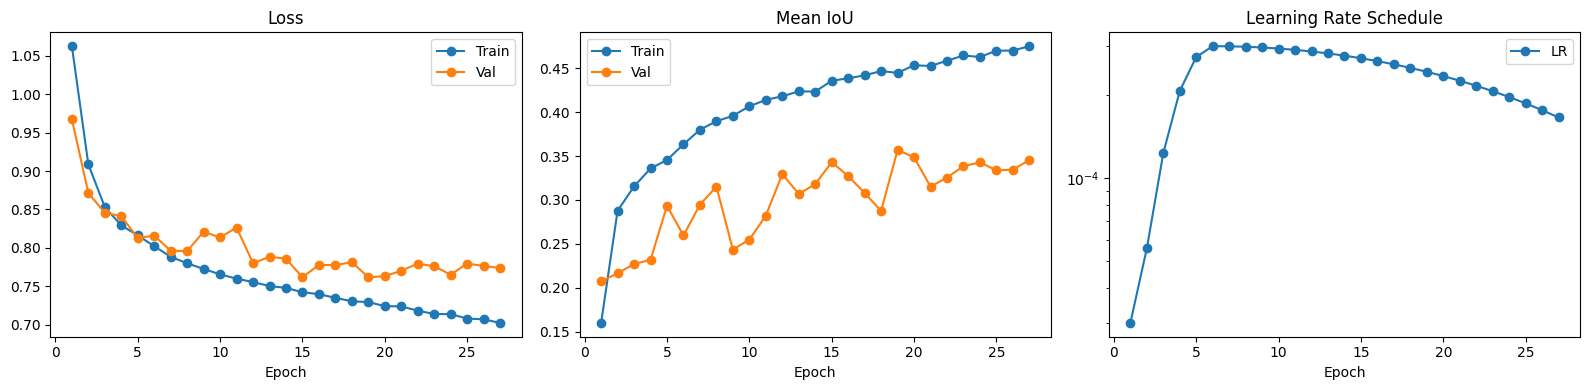

In [13]:
plot_train_history(history)

In [14]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=True)

Test Loss: 1.1464
Test mIoU: 0.3075
Test Acc:  0.8983

Class                IoU     Prec   Recall
No Damage         0.9164   0.9687   0.9444
Minor             0.5304   0.6021   0.8167
Major             0.0313   0.0967   0.0442
Destroyed         0.0505   0.2660   0.0587
Unclassified      0.0090   0.0126   0.0303
